# Process DWD Data by Geographical Location

This notebook processes all station directories and creates separate `produkt_tu_stunde` files for each unique latitude/longitude pair.

**Process:**
1. For each station directory, read `Metadaten_Geographie` and `produkt_tu_stunde` files
2. Group geography entries by unique (latitude, longitude) pairs
3. For each unique lat/lon pair, filter temperature data by date ranges
4. Add `latitude` and `longitude` columns to the data
5. Create separate CSV files for each location (including empty files when no data exists)
6. Save files in the same directory as input files


In [3]:
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import traceback


In [4]:
# Configuration
BASE_DIR = Path("/mnt/d/heatpump_data/climate_data/dwd_historical_hourly_temperature_extracted_csv")

print(f"Base directory: {BASE_DIR}")
print(f"Directory exists: {BASE_DIR.exists()}")


Base directory: /mnt/d/heatpump_data/climate_data/dwd_historical_hourly_temperature_extracted_csv
Directory exists: True


In [ ]:
def find_geography_and_produkt_files(station_dir):
    """
    Find Metadaten_Geographie and produkt_tu_stunde files in a station directory.
    
    Args:
        station_dir: Path to station directory
        
    Returns:
        Tuple of (geography_file_path, produkt_file_path) or (None, None) if not found
    """
    csv_files = list(station_dir.glob("*.csv"))
    
    geography_file = None
    produkt_file = None
    
    for f in csv_files:
        if "Metadaten_Geographie" in f.name:
            geography_file = f
        elif "produkt_tu_stunde" in f.name and "_lat_" not in f.name:
            # Only match original produkt files, not the ones we create
            produkt_file = f
    
    return geography_file, produkt_file


In [ ]:
def process_station_by_location(station_dir, verbose=False):
    """
    Process a single station: create separate produkt_tu_stunde files for each unique lat/lon pair.
    Creates files even when no data exists for a location (empty files with headers).
    
    Args:
        station_dir: Path to station directory containing CSV files
        verbose: If True, print detailed progress information
        
    Returns:
        Dictionary with processing results
    """
    # Find files
    geo_file, prod_file = find_geography_and_produkt_files(station_dir)
    
    if geo_file is None or prod_file is None:
        return {
            'status': 'skipped',
            'reason': 'Missing files',
            'geography_file': geo_file.name if geo_file else None,
            'produkt_file': prod_file.name if prod_file else None
        }
    
    try:
        # Read geography metadata
        geo_df = pd.read_csv(geo_file)
        
        # Read produkt temperature data
        prod_df = None
        if prod_file.exists():
            prod_df = pd.read_csv(prod_file)
            
            # Extract date from MESS_DATUM (first 8 characters: YYYYMMDD)
            prod_df['MESS_DATUM_date'] = pd.to_datetime(
                prod_df['MESS_DATUM'].astype(str).str[:8], 
                format='%Y%m%d',
                errors='coerce'
            )
        
        # Extract station ID
        station_id = geo_df['Stations_id'].iloc[0] if 'Stations_id' in geo_df.columns else None
        
        # Convert date columns to datetime for comparison
        geo_df['von_datum'] = pd.to_datetime(geo_df['von_datum'], format='%Y%m%d', errors='coerce')
        geo_df['bis_datum'] = pd.to_datetime(geo_df['bis_datum'], format='%Y%m%d', errors='coerce')
        
        # Group geography entries by unique (latitude, longitude) pairs
        location_groups = defaultdict(list)
        for idx, row in geo_df.iterrows():
            lat = row['Geogr.Breite']
            lon = row['Geogr.Laenge']
            location_groups[(lat, lon)].append({
                'von_datum': row['von_datum'],
                'bis_datum': row['bis_datum']
            })
        
        # Find the last known location (by latest bis_datum) for handling dates beyond geography ranges
        last_known_location = None
        if len(geo_df) > 0:
            # Find the row with the latest bis_datum
            valid_geo_rows = geo_df[geo_df['bis_datum'].notna()].copy()
            if len(valid_geo_rows) > 0:
                latest_idx = valid_geo_rows['bis_datum'].idxmax()
                last_known_location = {
                    'lat': valid_geo_rows.loc[latest_idx, 'Geogr.Breite'],
                    'lon': valid_geo_rows.loc[latest_idx, 'Geogr.Laenge'],
                    'bis_datum': valid_geo_rows.loc[latest_idx, 'bis_datum']
                }
        
        # Get column names from produkt file (for creating empty files)
        if prod_df is not None and len(prod_df) > 0:
            base_columns = list(prod_df.columns)
            # Remove temporary date column if it exists
            if 'MESS_DATUM_date' in base_columns:
                base_columns.remove('MESS_DATUM_date')
        else:
            # Default columns if no produkt file or empty
            base_columns = ['STATIONS_ID', 'MESS_DATUM', 'QN_9', 'TT_TU', 'RF_TU', 'eor']
        
        files_created = []
        files_with_data = 0
        files_empty = 0
        total_records = 0
        
        # Track which temperature data has been assigned to locations
        assigned_mask = None
        if prod_df is not None and len(prod_df) > 0:
            assigned_mask = pd.Series([False] * len(prod_df))
        
        # Process each unique location
        for (lat, lon), date_ranges in location_groups.items():
            filtered_prod = None
            
            if prod_df is not None and len(prod_df) > 0:
                # Combine all date ranges for this location
                combined_mask = pd.Series([False] * len(prod_df))
                
                for date_range in date_ranges:
                    von_date = date_range['von_datum']
                    bis_date = date_range['bis_datum']
                    
                    # Skip if dates are invalid
                    if pd.isna(von_date) or pd.isna(bis_date):
                        continue
                    
                    # Filter produkt data for this date range
                    mask = (
                        (prod_df['MESS_DATUM_date'] >= von_date) & 
                        (prod_df['MESS_DATUM_date'] <= bis_date)
                    )
                    combined_mask = combined_mask | mask
                
                filtered_prod = prod_df[combined_mask].copy()
                # Track assigned data
                if assigned_mask is not None:
                    assigned_mask = assigned_mask | combined_mask
            
            # Create output dataframe
            if filtered_prod is not None and len(filtered_prod) > 0:
                # Remove the temporary date column if it exists
                if 'MESS_DATUM_date' in filtered_prod.columns:
                    filtered_prod = filtered_prod.drop(columns=['MESS_DATUM_date'])
                
                # Add latitude and longitude columns
                filtered_prod['latitude'] = lat
                filtered_prod['longitude'] = lon
                
                record_count = len(filtered_prod)
                total_records += record_count
                files_with_data += 1
            else:
                # Create empty dataframe with proper columns
                filtered_prod = pd.DataFrame(columns=base_columns + ['latitude', 'longitude'])
                record_count = 0
                files_empty += 1
            
            # Create output filename
            base_name = prod_file.stem
            # Format lat/lon to avoid issues with decimal points in filenames
            lat_str = str(lat).replace('.', '_')
            lon_str = str(lon).replace('.', '_')
            output_filename = f"{base_name}_lat_{lat_str}_lon_{lon_str}.csv"
            output_path = station_dir / output_filename
            
            # Save to CSV in the same directory
            filtered_prod.to_csv(output_path, index=False)
            files_created.append(output_filename)
            
            if verbose and record_count > 0:
                print(f"    Created: {output_filename} ({record_count} records)")
            elif verbose:
                print(f"    Created: {output_filename} (empty file - no data in date range)")
        
        # Handle unassigned temperature data (dates before first geography date or after last geography date)
        if prod_df is not None and len(prod_df) > 0 and last_known_location is not None:
            unassigned_mask = ~assigned_mask
            unassigned_data = prod_df[unassigned_mask].copy()
            
            if len(unassigned_data) > 0:
                # Get date range of unassigned data
                min_date = unassigned_data['MESS_DATUM_date'].min()
                max_date = unassigned_data['MESS_DATUM_date'].max()
                
                # Use last known location for unassigned data
                lat = last_known_location['lat']
                lon = last_known_location['lon']
                
                # Remove the temporary date column if it exists
                if 'MESS_DATUM_date' in unassigned_data.columns:
                    unassigned_data = unassigned_data.drop(columns=['MESS_DATUM_date'])
                
                # Add latitude and longitude columns
                unassigned_data['latitude'] = lat
                unassigned_data['longitude'] = lon
                
                # Create filename with actual date range
                start_date_str = min_date.strftime('%Y%m%d')
                end_date_str = max_date.strftime('%Y%m%d')
                lat_str = str(lat).replace('.', '_')
                lon_str = str(lon).replace('.', '_')
                
                output_filename = f"produkt_tu_stunde_{start_date_str}_{end_date_str}_{station_id:05d}_lat_{lat_str}_lon_{lon_str}.csv"
                output_path = station_dir / output_filename
                
                # Save unassigned data
                unassigned_data.to_csv(output_path, index=False)
                files_created.append(output_filename)
                
                record_count = len(unassigned_data)
                total_records += record_count
                files_with_data += 1
                
                if verbose:
                    print(f"    Created (unassigned dates): {output_filename} ({record_count} records)")
        
        return {
            'status': 'success',
            'station_id': station_id,
            'unique_locations': len(location_groups),
            'files_created': len(files_created),
            'files_with_data': files_with_data,
            'files_empty': files_empty,
            'total_records': total_records,
            'files': files_created
        }
        
    except Exception as e:
        return {
            'status': 'error',
            'error': str(e),
            'traceback': traceback.format_exc(),
            'station_dir': str(station_dir)
        }


In [ ]:
# Get all station directories
station_dirs = [d for d in BASE_DIR.iterdir() if d.is_dir()]
station_dirs.sort()

print(f"Found {len(station_dirs)} station directories to process")


Found 636 station directories to process


In [ ]:
# Process all stations
print("=" * 80)
print("Processing all stations...")
print("=" * 80)

results = []
success_count = 0
error_count = 0
skipped_count = 0

for station_dir in tqdm(station_dirs, desc="Processing stations", unit="station"):
    result = process_station_by_location(station_dir, verbose=False)
    result['station_dir'] = station_dir.name
    results.append(result)
    
    if result['status'] == 'success':
        success_count += 1
    elif result['status'] == 'error':
        error_count += 1
    elif result['status'] == 'skipped':
        skipped_count += 1

print("\n" + "=" * 80)
print("Processing complete!")
print("=" * 80)


Processing all stations...


Processing stations: 100%|██████████| 636/636 [18:37<00:00,  1.76s/station]


Processing complete!


In [ ]:
# Summary statistics
print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

print(f"\nTotal stations processed: {len(results)}")
print(f"  Successfully processed: {success_count}")
print(f"  Errors: {error_count}")
print(f"  Skipped: {skipped_count}")

# Aggregate statistics from successful processing
successful_results = [r for r in results if r['status'] == 'success']

if successful_results:
    total_locations = sum(r['unique_locations'] for r in successful_results)
    total_files = sum(r['files_created'] for r in successful_results)
    total_files_with_data = sum(r.get('files_with_data', 0) for r in successful_results)
    total_files_empty = sum(r.get('files_empty', 0) for r in successful_results)
    total_records = sum(r.get('total_records', 0) for r in successful_results)
    
    print(f"\nFiles created:")
    print(f"  Total unique locations: {total_locations}")
    print(f"  Total files created: {total_files}")
    print(f"  Files with data: {total_files_with_data}")
    print(f"  Empty files: {total_files_empty}")
    print(f"  Total records: {total_records:,}")

# Show stations with errors
error_results = [r for r in results if r['status'] == 'error']
if error_results:
    print(f"\n{'=' * 80}")
    print(f"STATIONS WITH ERRORS ({len(error_results)}):")
    print("=" * 80)
    for r in error_results[:10]:  # Show first 10 errors
        print(f"\nStation: {r['station_dir']}")
        print(f"Error: {r['error']}")
    if len(error_results) > 10:
        print(f"\n... and {len(error_results) - 10} more errors")



SUMMARY STATISTICS

Total stations processed: 636
  Successfully processed: 636
  Errors: 0
  Skipped: 0

Files created:
  Total unique locations: 2567
  Total files created: 2984
  Files with data: 1003
  Empty files: 1981
  Total records: 139,250,150


In [ ]:
# Show stations that were skipped
skipped_results = [r for r in results if r['status'] == 'skipped']
if skipped_results:
    print(f"\n{'=' * 80}")
    print(f"SKIPPED STATIONS ({len(skipped_results)}):")
    print("=" * 80)
    for r in skipped_results[:10]:  # Show first 10
        print(f"  {r['station_dir']}: {r.get('reason', 'Unknown reason')}")
    if len(skipped_results) > 10:
        print(f"\n... and {len(skipped_results) - 10} more skipped")


In [ ]:
# Sample verification - check a few stations
print("\n" + "=" * 80)
print("SAMPLE VERIFICATION")
print("=" * 80)

sample_stations = [r for r in successful_results[:3]]

for result in sample_stations:
    station_dir = BASE_DIR / result['station_dir']
    output_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    print(f"\nStation: {result['station_dir']}")
    print(f"  Station ID: {result.get('station_id', 'N/A')}")
    print(f"  Unique locations: {result['unique_locations']}")
    print(f"  Files created: {result['files_created']}")
    print(f"  Files with data: {result.get('files_with_data', 0)}")
    print(f"  Empty files: {result.get('files_empty', 0)}")
    print(f"  Total records: {result.get('total_records', 0):,}")
    
    if output_files:
        print(f"  Sample files:")
        for f in sorted(output_files)[:3]:
            size_kb = f.stat().st_size / 1024
            df_check = pd.read_csv(f)
            record_count = len(df_check)
            print(f"    - {f.name} ({size_kb:.1f} KB, {record_count} records)")



SAMPLE VERIFICATION

Station: stundenwerte_TU_00003_19500401_20110331_hist
  Station ID: 3
  Unique locations: 4
  Files created: 4
  Files with data: 1
  Empty files: 3
  Total records: 534,719
  Sample files:
    - produkt_tu_stunde_19500401_20110331_00003_lat_50_7667_lon_6_0833.csv (0.1 KB, 0 records)
    - produkt_tu_stunde_19500401_20110331_00003_lat_50_7827_lon_6_0941.csv (22855.4 KB, 534719 records)
    - produkt_tu_stunde_19500401_20110331_00003_lat_50_7833_lon_6_0833.csv (0.1 KB, 0 records)

Station: stundenwerte_TU_00044_20070401_20241231_hist
  Station ID: 44
  Unique locations: 4
  Files created: 5
  Files with data: 1
  Empty files: 4
  Total records: 154,851
  Sample files:
    - produkt_tu_stunde_20070401_20241231_00044_lat_52_8846_lon_8_2308.csv (0.1 KB, 0 records)
    - produkt_tu_stunde_20070401_20241231_00044_lat_52_89_lon_8_23.csv (0.1 KB, 0 records)
    - produkt_tu_stunde_20070401_20241231_00044_lat_52_9164_lon_8_2211.csv (6753.5 KB, 154851 records)

Station: stu

# Rename lat/lon files with correct date ranges based on actual data in each file


In [61]:
# Rename lat/lon files with correct date ranges based on actual data in each file
print("=" * 80)
print("Renaming lat/lon files with correct date ranges...")
print("=" * 80)

files_renamed = 0
files_skipped = 0
errors = 0

for station_dir in tqdm(station_dirs, desc="Renaming files", unit="station"):
    # Find all lat/lon files for this station
    lat_lon_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    for file_path in lat_lon_files:
        try:
            # Read the CSV file to get actual date range
            df = pd.read_csv(file_path)
            
            if len(df) == 0:
                # Skip empty files
                files_skipped += 1
                continue
            
            # Extract dates from MESS_DATUM column
            df['MESS_DATUM_str'] = df['MESS_DATUM'].astype(str).str[:8]
            df['date'] = pd.to_datetime(df['MESS_DATUM_str'], format='%Y%m%d', errors='coerce')
            
            # Get min and max dates
            valid_dates = df['date'].dropna()
            if len(valid_dates) == 0:
                files_skipped += 1
                continue
            
            min_date = valid_dates.min()
            max_date = valid_dates.max()
            
            # Format dates as YYYYMMDD
            start_date_str = min_date.strftime('%Y%m%d')
            end_date_str = max_date.strftime('%Y%m%d')
            
            # Extract station ID, lat, lon from filename or data
            filename = file_path.name
            
            # Try to get station ID from data first
            station_id = None
            if 'STATIONS_ID' in df.columns:
                station_id = df['STATIONS_ID'].iloc[0]
            
            # If not in data, try to extract from filename
            if station_id is None:
                # Try to extract from filename pattern: produkt_tu_stunde_*_*_*_lat_*_lon_*.csv
                parts = filename.split('_')
                for i, part in enumerate(parts):
                    if part.isdigit() and len(part) == 5:
                        station_id = int(part)
                        break
            
            # Extract lat/lon from filename
            lat_str = None
            lon_str = None
            if '_lat_' in filename and '_lon_' in filename:
                parts = filename.split('_lat_')
                if len(parts) >= 2:
                    lat_lon_part = parts[1].replace('.csv', '')
                    lon_part = lat_lon_part.split('_lon_')
                    if len(lon_part) >= 2:
                        lat_str = lon_part[0]
                        lon_str = lon_part[1].split('_lat_')[0].split('_lon_')[0]
            
            # If lat/lon not in filename, get from data
            if lat_str is None or lon_str is None:
                if 'latitude' in df.columns and 'longitude' in df.columns:
                    lat = df['latitude'].iloc[0]
                    lon = df['longitude'].iloc[0]
                    lat_str = str(lat).replace('.', '_')
                    lon_str = str(lon).replace('.', '_')
            
            if station_id is None or lat_str is None or lon_str is None:
                files_skipped += 1
                continue
            
            # Create new filename with correct date range
            new_filename = f"produkt_tu_stunde_{start_date_str}_{end_date_str}_{station_id:05d}_lat_{lat_str}_lon_{lon_str}.csv"
            new_file_path = station_dir / new_filename
            
            # Skip if already correctly named
            if filename == new_filename:
                continue
            
            # Rename the file
            file_path.rename(new_file_path)
            files_renamed += 1
            
        except Exception as e:
            errors += 1
            # Silently skip errors or print if needed
            continue

print(f"\nRenaming complete!")
print(f"  Files renamed: {files_renamed}")
print(f"  Files skipped: {files_skipped}")
print(f"  Errors: {errors}")


Renaming lat/lon files with correct date ranges...


Renaming files: 100%|██████████| 636/636 [04:38<00:00,  2.28station/s]


Renaming complete!
  Files renamed: 512
  Files skipped: 1791
  Errors: 0


# Assign new IDs to stations with multiple lat/long files

In [66]:
# Assign new IDs to stations with multiple lat/long files
# Change station IDs from 3 to 3_1, 3_2, etc. for each lat/long file
print("=" * 80)
print("Assigning new IDs to stations with multiple lat/long files...")
print("=" * 80)

import re

files_renamed = 0
files_updated = 0
errors = 0
stations_processed = 0

# Process each station directory separately
for station_dir in tqdm(station_dirs, desc="Assigning new IDs", unit="station"):
    # Find all lat/lon files for this station
    lat_lon_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    if len(lat_lon_files) <= 1:
        # Skip stations with only one file
        continue
    
    stations_processed += 1
    
    # Extract station_id from first file
    try:
        first_file = lat_lon_files[0]
        filename = first_file.name
        # Pattern: produkt_tu_stunde_*_*_*_lat_*_lon_*.csv
        # Station ID is the 5-digit number before _lat_
        match = re.search(r'_(\d{5})_lat_', filename)
        if not match:
            # Try to get from CSV data
            df_temp = pd.read_csv(first_file)
            if 'STATIONS_ID' in df_temp.columns:
                station_id = int(df_temp['STATIONS_ID'].iloc[0])
            else:
                errors += 1
                continue
        else:
            station_id = int(match.group(1))
    except Exception as e:
        errors += 1
        continue
    
    # Sort files by filename for consistent ordering
    lat_lon_files.sort(key=lambda x: x.name)
    
    # Assign new IDs: station_id_1, station_id_2, etc.
    for idx, file_path in enumerate(lat_lon_files, start=1):
        try:
            # Read the CSV file
            df = pd.read_csv(file_path)
            
            # Create new station ID
            new_station_id = f"{station_id}_{idx}"
            
            # Update STATIONS_ID column in dataframe
            if 'STATIONS_ID' in df.columns:
                df['STATIONS_ID'] = new_station_id
            else:
                # If column doesn't exist, add it
                df.insert(0, 'STATIONS_ID', new_station_id)
            
            # Extract components from current filename
            filename = file_path.name
            # Pattern: produkt_tu_stunde_{start_date}_{end_date}_{old_station_id:05d}_lat_{lat}_lon_{lon}.csv
            # Replace the 5-digit station ID with new_station_id
            new_filename = re.sub(r'_(\d{5})_lat_', f'_{new_station_id}_lat_', filename)
            
            new_file_path = file_path.parent / new_filename
            
            # Save updated dataframe
            df.to_csv(new_file_path, index=False)
            
            # Remove old file if filename changed
            if new_file_path != file_path:
                file_path.unlink()
                files_renamed += 1
            else:
                files_updated += 1
                
        except Exception as e:
            errors += 1
            continue

print(f"\nID assignment complete!")
print(f"  Files renamed: {files_renamed}")
print(f"  Files updated (same name): {files_updated}")
print(f"  Errors: {errors}")
print(f"  Stations with multiple files processed: {stations_processed}")


Assigning new IDs to stations with multiple lat/long files...


Assigning new IDs: 100%|██████████| 636/636 [16:13<00:00,  1.53s/station]


ID assignment complete!
  Files renamed: 2656
  Files updated (same name): 0
  Errors: 2
  Stations with multiple files processed: 500


## Remove Existing Lat/Lon Temperature Files if reprocessing needed

Remove all existing lat/lon temperature files to allow regeneration with updated processing logic.


In [51]:
# Remove all existing lat/lon temperature files
print("=" * 80)
print("Removing existing lat/lon temperature files...")
print("=" * 80)

files_removed = 0
errors = 0

for station_dir in tqdm(station_dirs, desc="Removing files", unit="station"):
    # Find all lat/lon files for this station
    lat_lon_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    for file_path in lat_lon_files:
        try:
            file_path.unlink()  # Delete the file
            files_removed += 1
        except Exception as e:
            errors += 1
            print(f"Error removing {file_path.name}: {str(e)}")

print(f"\nRemoval complete!")
print(f"  Files removed: {files_removed}")
print(f"  Errors: {errors}")


Removing existing lat/lon temperature files...


Removing files: 100%|██████████| 636/636 [00:02<00:00, 220.72station/s]


Removal complete!
  Files removed: 2
  Errors: 0


# Exploring postal code data

## Getting Germany's map with postal code boundaries 

Source of postal code map: https://www.kaggle.com/datasets/jonaslneri/germany-plz

In [10]:
!uv pip install geopandas tabulate

Using Python 3.11.14 environment at: /home/abhishek/Documents/heatpump_ai_2/climate_data_prep/.venv
Resolved 13 packages in 200ms                                        
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)-------------------     0 B/34.43 KiB           
⠙ Preparing packages... (0/1)2m----------------- 16.00 KiB/34.43 KiB         
⠙ Preparing packages... (0/1)---------- 32.00 KiB/34.43 KiB         
⠙ Preparing packages... (0/1)---------- 34.43 KiB/34.43 KiB         
Prepared 1 package in 18ms                                                        
Installed 1 package in 4ms                                  
 + tabulate==0.9.0


In [16]:
!uv pip install matplotlib

Using Python 3.11.14 environment at: /home/abhishek/Documents/heatpump_ai_2/climate_data_prep/.venv
Resolved 11 packages in 270ms                                        
⠙ Preparing packages... (0/6)                                                   
⠙ Preparing packages... (0/6)-------------------     0 B/4.80 MiB            
⠙ Preparing packages... (0/6)------------------- 16.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 32.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 48.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
contourpy            ------------------------------     0 B/346.91 KiB
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.80 MiB          
contourpy            ------------------------------     0 B/346.91 KiB
⠙ Preparing packages... (0/6)------------------- 64.00 KiB/4.

In [2]:
import geopandas as gpd
from tabulate import tabulate

In [26]:


file_name = "plz-5stellig.shp"
path = f"/mnt/d/heatpump_data/postal_code_data/postal_code_map/{file_name}"
plz = gpd.read_file(path)  # adjust filename if needed

In [27]:
print()
print(tabulate(plz.head(), headers="keys", tablefmt="grid", showindex=False))


+-------+--------------------------------+-------------+-----------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [28]:
print(plz.crs)
print(plz.columns)

EPSG:4326
Index(['plz', 'note', 'einwohner', 'qkm', 'geometry'], dtype='object')


In [29]:
plz = plz.to_crs("EPSG:4326")

In [30]:
print(tabulate(plz.head(), headers="keys", tablefmt="grid", showindex=False))

+-------+--------------------------------+-------------+-----------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [31]:
# plz.describe()
plz["qkm"].describe()

count    8170.000000
mean       43.730761
std        52.647218
min         0.001829
25%        12.745523
50%        27.278689
75%        56.223991
max       891.886712
Name: qkm, dtype: float64

<Axes: >

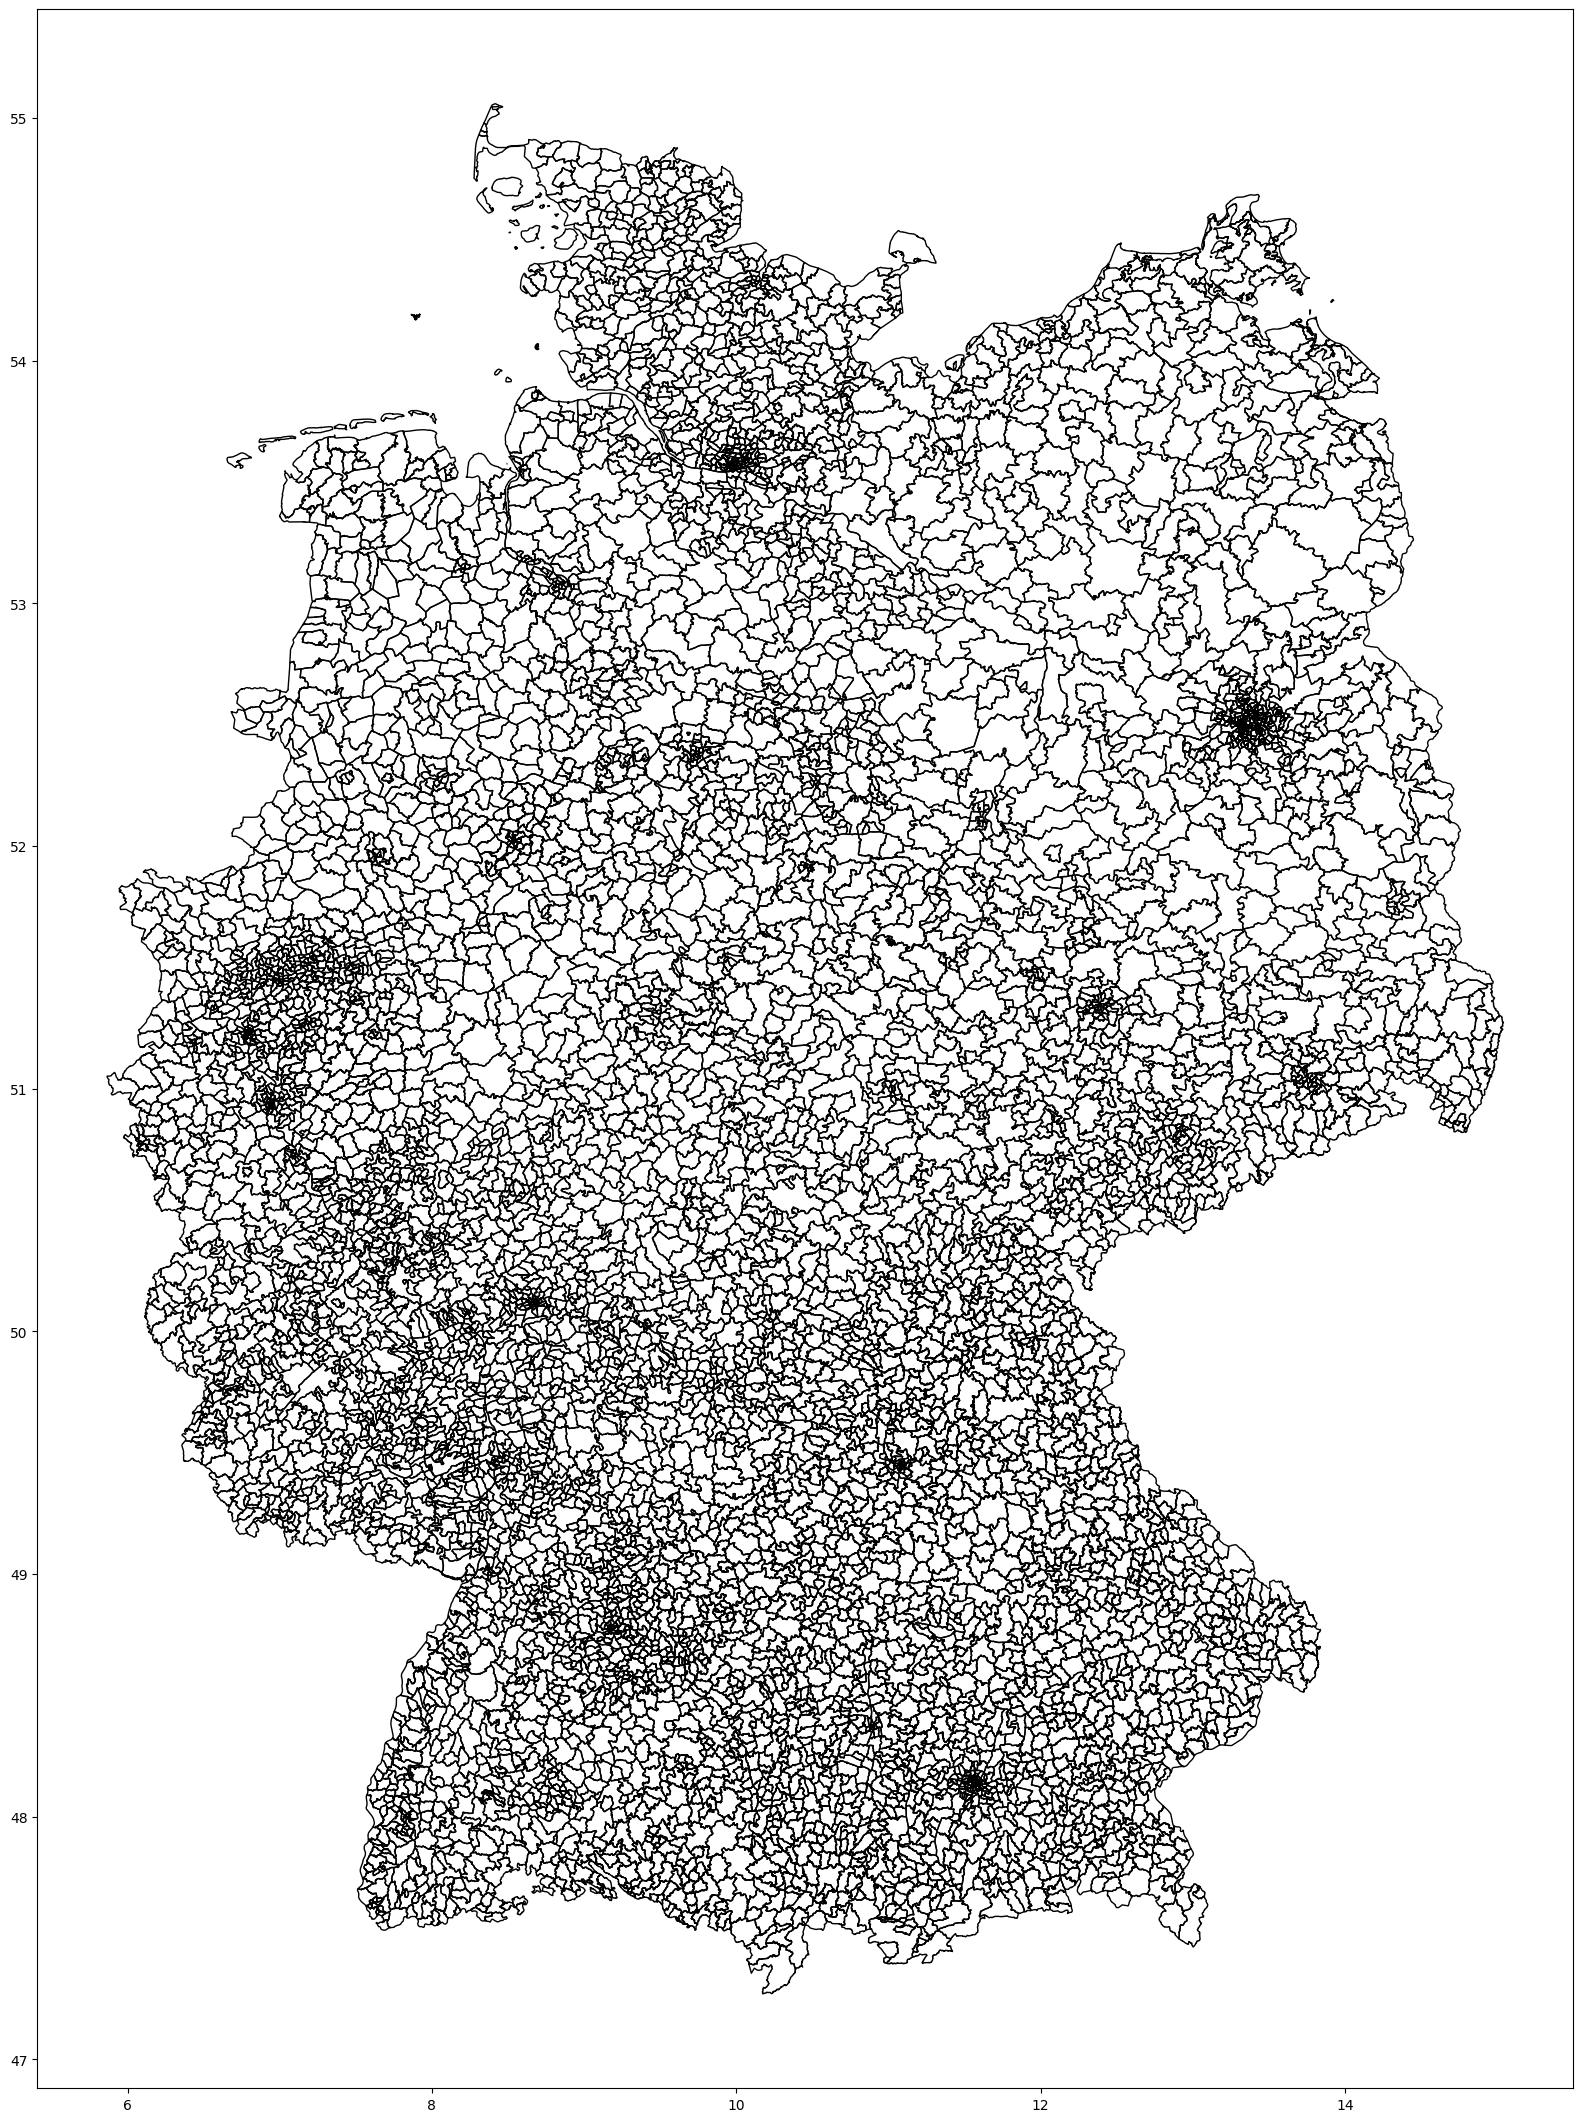

In [32]:
plz.plot(figsize=(21, 27), edgecolor="black", facecolor="none")

## Extract Station Coordinates and Plot on Postal Code Map

Extract coordinates from all temperature files with lat/lon and plot them on the Germany postal code map.


In [62]:
# Extract coordinates from all lat/lon temperature files
print("=" * 80)
print("Extracting station coordinates from temperature files...")
print("=" * 80)

station_coords = []
files_processed = 0
files_with_data = 0
files_empty = 0

for station_dir in tqdm(station_dirs, desc="Extracting coordinates", unit="station"):
    # Find all lat/lon files for this station
    lat_lon_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    for file_path in lat_lon_files:
        files_processed += 1
        try:
            # Read the CSV file
            df = pd.read_csv(file_path)
            
            if len(df) == 0:
                files_empty += 1
                continue
            
            # Get unique station ID, lat, lon from the file
            station_id = df['STATIONS_ID'].iloc[0] if 'STATIONS_ID' in df.columns else None
            lat = df['latitude'].iloc[0] if 'latitude' in df.columns else None
            lon = df['longitude'].iloc[0] if 'longitude' in df.columns else None
            
            if station_id is not None and lat is not None and lon is not None:
                # Add all coordinates, even if they're at the same location
                # This allows plotting multiple points at the same location
                station_coords.append({
                    'station_id': station_id,
                    'latitude': lat,
                    'longitude': lon,
                    'file': file_path.name,
                    'records': len(df)
                })
                files_with_data += 1
            
        except Exception as e:
            # Silently skip errors
            continue

print(f"\nExtraction complete!")
print(f"  Total files processed: {files_processed}")
print(f"  Files with data: {files_with_data}")
print(f"  Empty files: {files_empty}")
print(f"  Total coordinates extracted: {len(station_coords)}")


Extracting station coordinates from temperature files...


Extracting coordinates: 100%|██████████| 636/636 [02:46<00:00,  3.82station/s]


Extraction complete!
  Total files processed: 2794
  Files with data: 1003
  Empty files: 1791
  Total coordinates extracted: 1003


In [63]:
# Create GeoDataFrame from station coordinates
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Create a DataFrame from station coordinates
coords_df = pd.DataFrame(station_coords)

# Create geometry column from lat/lon (Note: Point takes lon, lat order)
coords_df['geometry'] = coords_df.apply(
    lambda row: Point(row['longitude'], row['latitude']), 
    axis=1
)

# Create GeoDataFrame with same CRS as postal code map (EPSG:4326)
stations_gdf = gpd.GeoDataFrame(coords_df, geometry='geometry', crs='EPSG:4326')

# Ensure postal code map is also in EPSG:4326
if plz.crs != 'EPSG:4326':
    plz = plz.to_crs('EPSG:4326')

print(f"Created GeoDataFrame with {len(stations_gdf)} station locations")
print(f"Station CRS: {stations_gdf.crs}")
print(f"Postal code CRS: {plz.crs}")
print(f"\nSample coordinates:")
print(stations_gdf[['station_id', 'latitude', 'longitude', 'records']].head(10))


Created GeoDataFrame with 1003 station locations
Station CRS: EPSG:4326
Postal code CRS: EPSG:4326

Sample coordinates:
   station_id  latitude  longitude  records
0           3   50.7827     6.0941   534719
1          44   52.9164     8.2211   154851
2          52   53.6623    10.1990   105192
3          71   48.2156     8.9784    88391
4          73   48.6159    13.0506   144087
5          73   48.6159    13.0506    10992
6          78   52.5026     7.9468   176781
7          91   50.7447     9.3451   178239
8          96   52.9475    12.8618    50247
9         102   53.8633     8.1275   186537


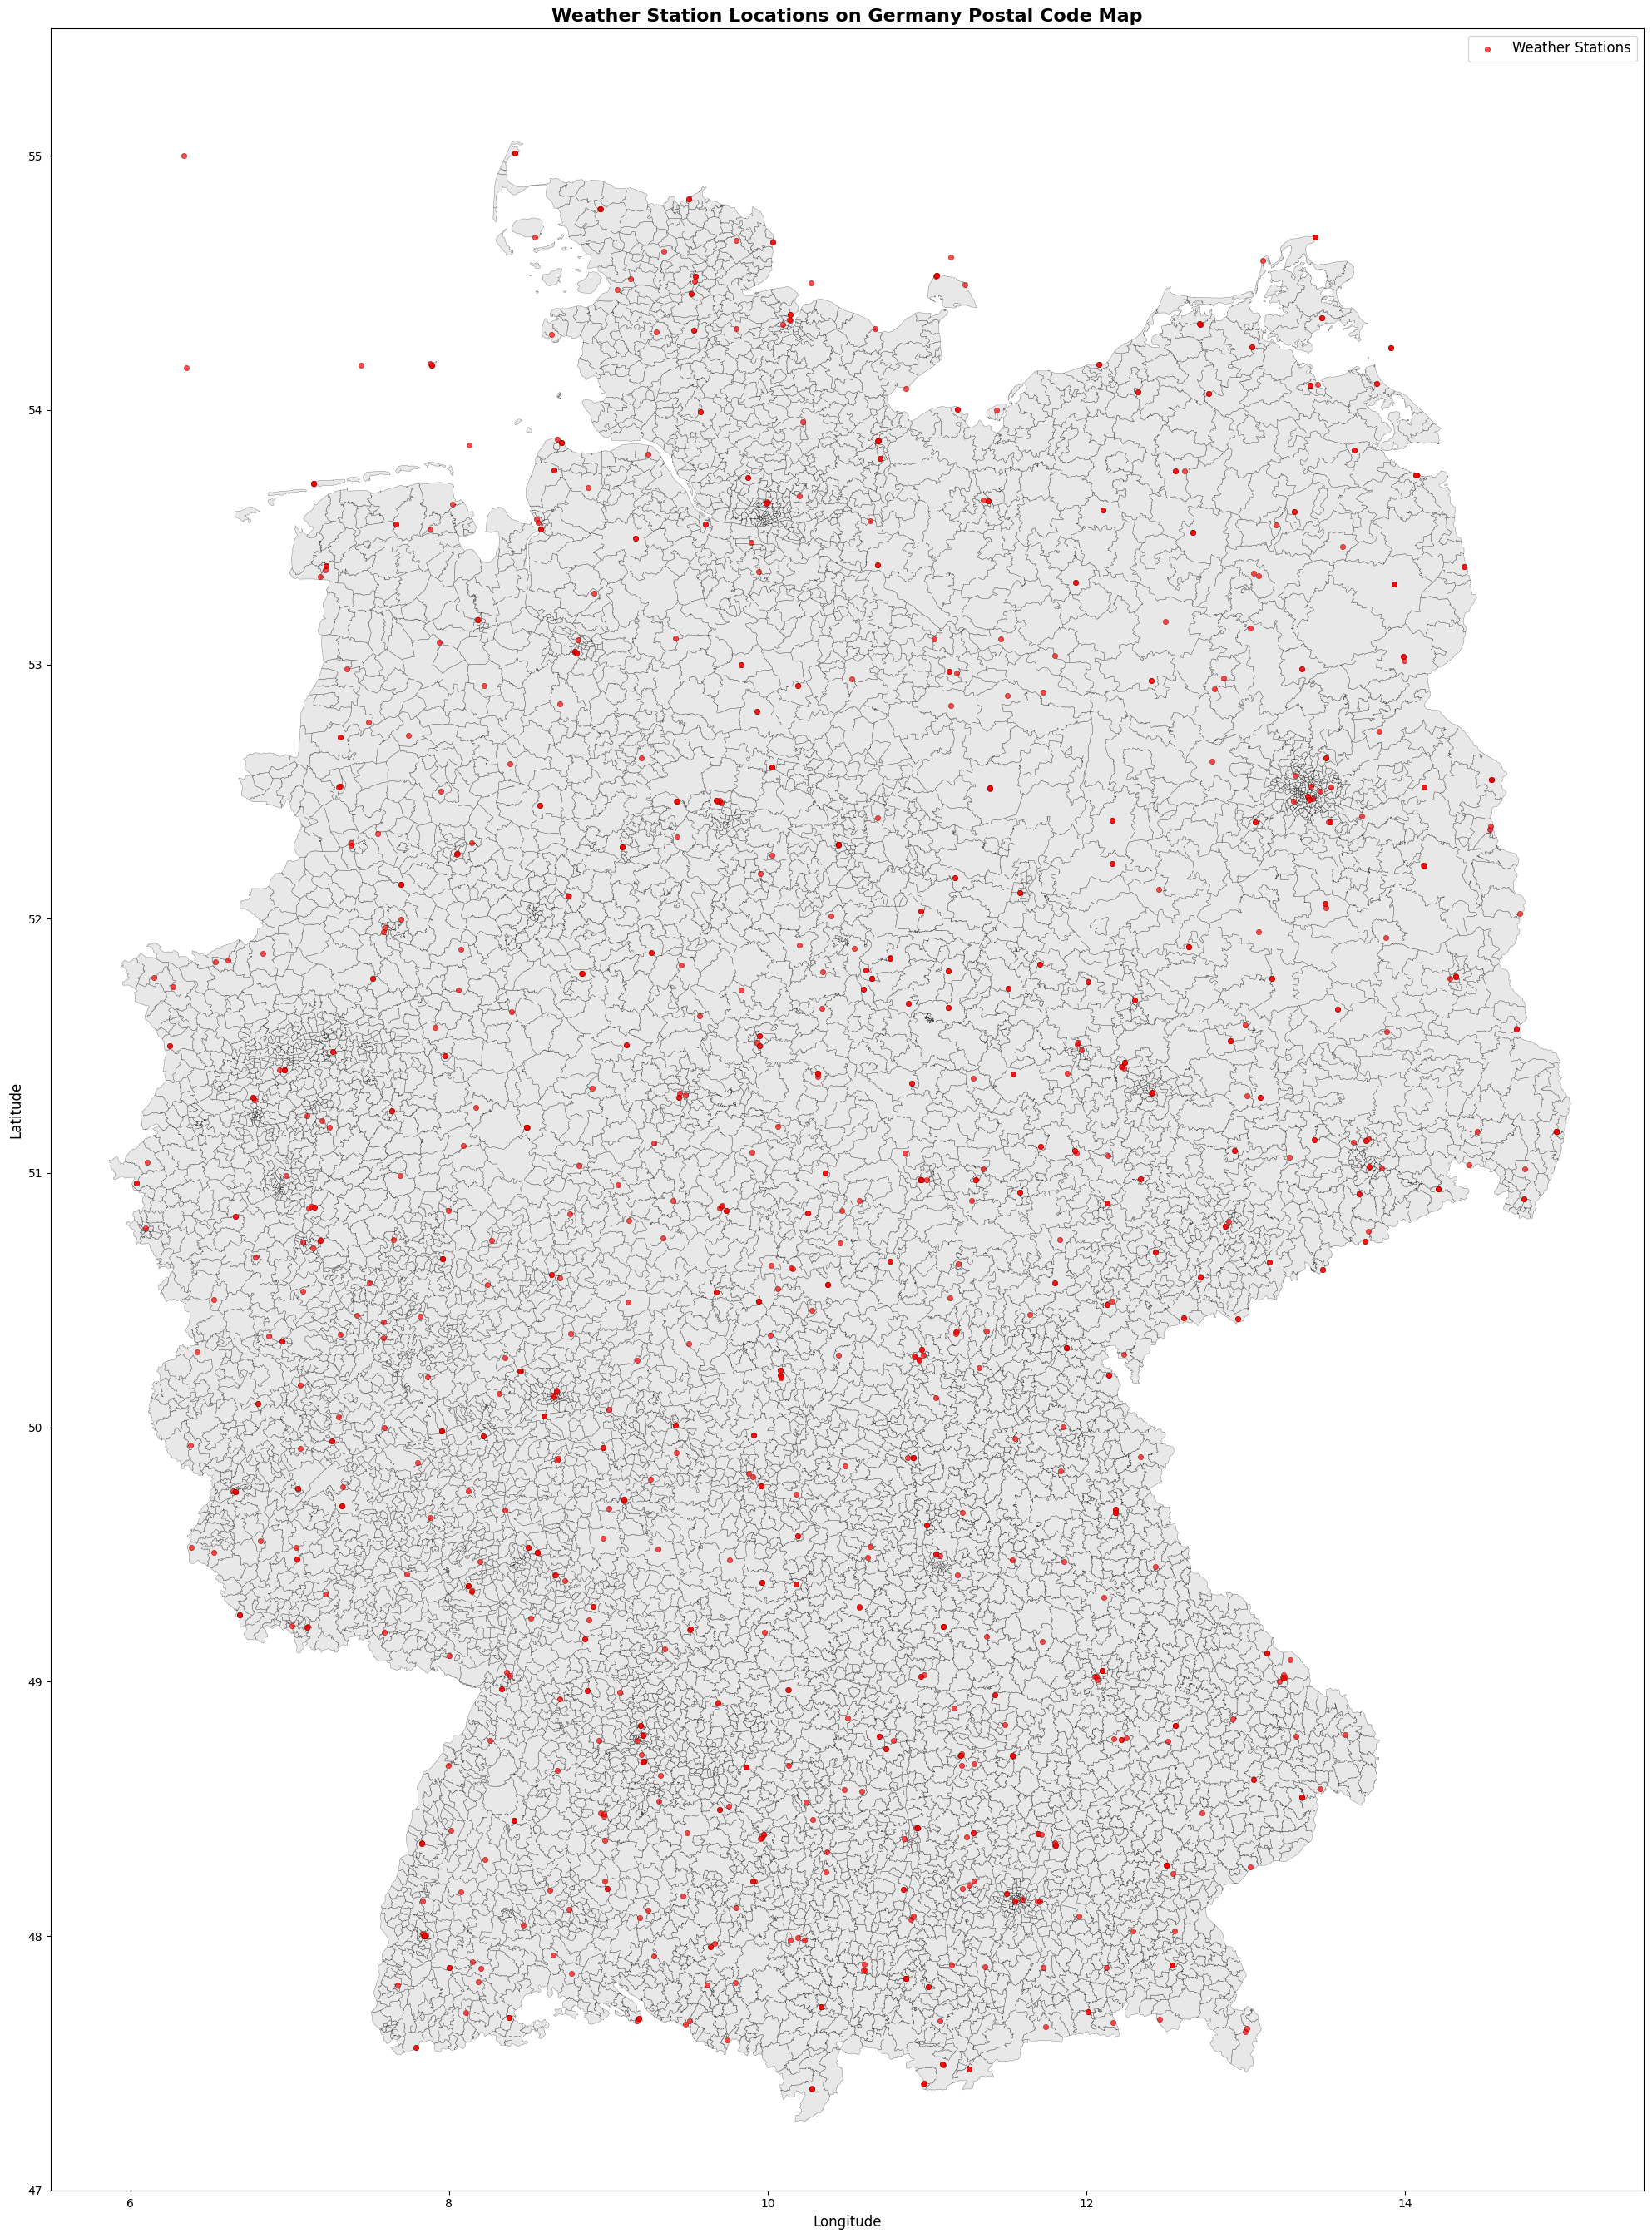


Plotted 1003 weather station locations on the map


In [ ]:
# Plot stations on the postal code map
fig, ax = plt.subplots(figsize=(21, 27))

# Plot postal code boundaries (same as before)
plz.plot(ax=ax, edgecolor='black', facecolor='lightgray', linewidth=0.3, alpha=0.5)

# Plot station coordinates
stations_gdf.plot(ax=ax, color='red', markersize=20, marker='o', 
                  edgecolor='darkred', linewidth=0.5, label='Weather Stations', alpha=0.7)

# Set labels and title
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Weather Station Locations on Germany Postal Code Map', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)

# Set axis limits to Germany's bounds (approximately)
ax.set_xlim([5.5, 15.5])  # Longitude range for Germany
ax.set_ylim([47.0, 55.5])  # Latitude range for Germany

plt.tight_layout()
plt.show()

print(f"\nPlotted {len(stations_gdf)} weather station locations on the map")


In [65]:
# Additional statistics about station distribution
print("\n" + "=" * 80)
print("STATION COORDINATE STATISTICS")
print("=" * 80)

print(f"\nTotal station locations: {len(stations_gdf)}")
print(f"\nGeographic bounds:")
print(f"  Latitude range: {stations_gdf['latitude'].min():.4f} to {stations_gdf['latitude'].max():.4f}")
print(f"  Longitude range: {stations_gdf['longitude'].min():.4f} to {stations_gdf['longitude'].max():.4f}")

print(f"\nRecords per station:")
print(f"  Min records: {stations_gdf['records'].min():,}")
print(f"  Max records: {stations_gdf['records'].max():,}")
print(f"  Mean records: {stations_gdf['records'].mean():,.0f}")
print(f"  Median records: {stations_gdf['records'].median():,.0f}")

# Show stations with most records
print(f"\nTop 10 stations by record count:")
top_stations = stations_gdf.nlargest(10, 'records')[['station_id', 'latitude', 'longitude', 'records']]
print(top_stations.to_string(index=False))



STATION COORDINATE STATISTICS

Total station locations: 1003

Geographic bounds:
  Latitude range: 47.3981 to 55.0110
  Longitude range: 6.0392 to 14.9557

Records per station:
  Min records: 23
  Max records: 1,143,994
  Mean records: 138,834
  Median records: 133,817

Top 10 stations by record count:
 station_id  latitude  longitude  records
       3987   52.3812    13.0622  1143994
        198   51.3743    11.2917   560954
       2290   47.8009    11.0108   548180
       4271   54.1802    12.0805   537446
          3   50.7827     6.0941   534719
       4625   53.6424    11.3871   521994
       2638   48.1052     8.7544   521371
       2601   50.2221     8.4491   510990
       5792   47.4210    10.9848   506580
       1358   50.4283    12.9536   504734


# Check stations where all lat/lon files are empty


In [5]:
# Check stations where all lat/lon files are empty
print("\n" + "=" * 80)
print("Checking for stations with all empty lat/lon files...")
print("=" * 80)

stations_all_empty = []
stations_with_some_data = []
stations_no_files = []

for station_dir in tqdm(station_dirs, desc="Checking stations", unit="station"):
    lat_lon_files = list(station_dir.glob("produkt_tu_stunde_*_lat_*_lon_*.csv"))
    
    if len(lat_lon_files) == 0:
        stations_no_files.append(station_dir.name)
        continue
    
    # Check if all files are empty
    all_empty = True
    has_data = False
    
    for file_path in lat_lon_files:
        try:
            df = pd.read_csv(file_path)
            if len(df) > 0:
                all_empty = False
                has_data = True
                break
        except Exception as e:
            # If we can't read the file, consider it empty
            continue
    
    if all_empty:
        stations_all_empty.append(station_dir.name)
    elif has_data:
        stations_with_some_data.append(station_dir.name)

print(f"\nResults:")
print(f"  Stations with all files empty: {len(stations_all_empty)}")
print(f"  Stations with at least one file with data: {len(stations_with_some_data)}")
print(f"  Stations with no lat/lon files: {len(stations_no_files)}")

if stations_all_empty:
    print(f"\n{'=' * 80}")
    print(f"STATIONS WITH ALL EMPTY FILES ({len(stations_all_empty)}):")
    print("=" * 80)
    for station in stations_all_empty:
        print(f"  - {station}")
    
    if len(stations_all_empty) > 20:
        print(f"\n... and {len(stations_all_empty) - 20} more stations")
else:
    print("\nNo stations found with all empty files!")

if stations_no_files:
    print(f"\n{'=' * 80}")
    print(f"STATIONS WITH NO LAT/LON FILES ({len(stations_no_files)}):")
    print("=" * 80)
    for station in stations_no_files[:20]:
        print(f"  - {station}")
    
    if len(stations_no_files) > 20:
        print(f"\n... and {len(stations_no_files) - 20} more stations")



Checking for stations with all empty lat/lon files...


NameError: name 'station_dirs' is not defined